<a href="https://colab.research.google.com/github/prathik002/DataScience-Lab/blob/main/Program_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Dataset: <Breast_Cancer.csv>

a) Conduct exploratory data analysis on the given dataset and report
the details.

b) Visualize the analysis results using (i) scatter plot (ii) histogram &
(iii) box plot.

c) Implement the Naïve Bayes classification algorithm using the
dataset. Display the classification report with the accuracy.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score


In [4]:
# a) Conduct exploratory data analysis
df = pd.read_csv('/content/Breast-cancer.csv')  # laod the breast cancer dataset
print(df.head())    # first few rows
print(df.isnull().sum())   # checks for missing values
print(df.describe())    # Summary statistics of the dataset

# Target variable distribution('if the dataset contains target classes, such as 'diagnosis')
if 'diagnosis' in df.columns:
  print(df['diagnosis'].value_counts())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

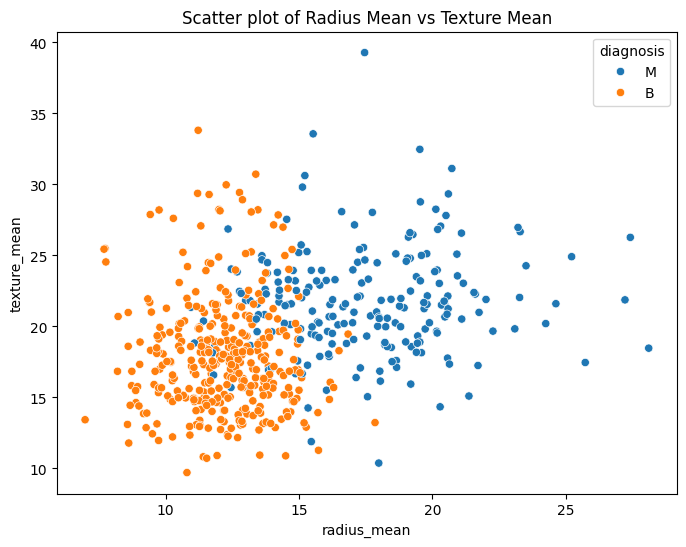

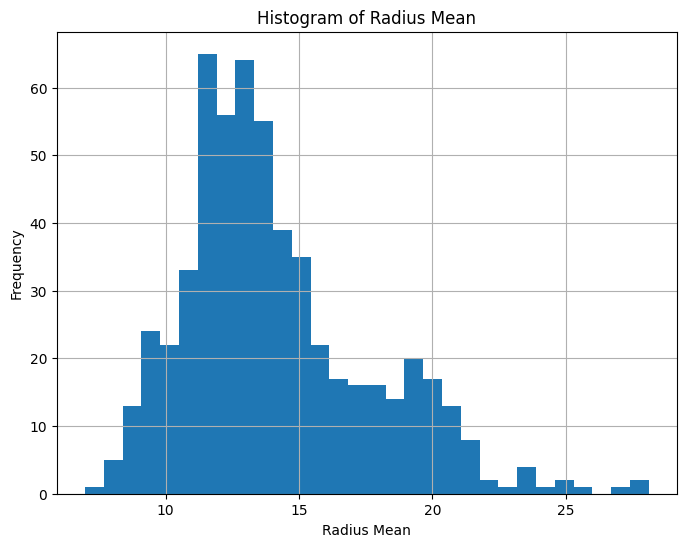

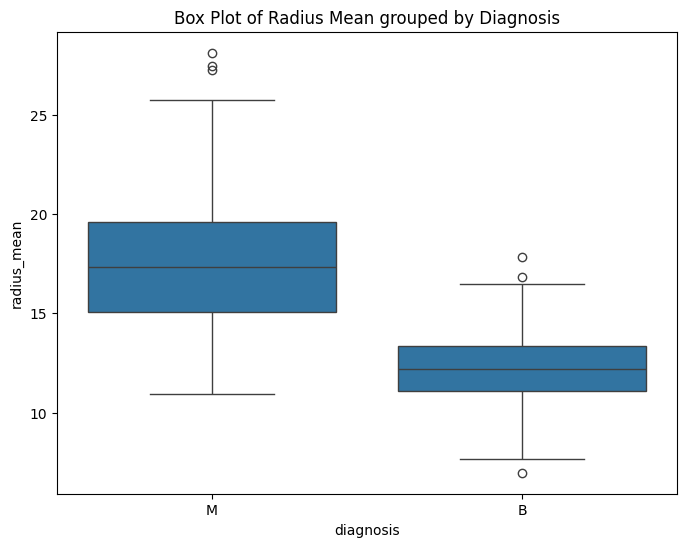

In [8]:
# b) Visualzation

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='radius_mean',y='texture_mean',data=df,hue='diagnosis')
plt.title('Scatter plot of Radius Mean vs Texture Mean')
plt.show()

# Histogram
plt.figure(figsize=(8,6))
df['radius_mean'].hist(bins=30)
plt.title('Histogram of Radius Mean')
plt.xlabel('Radius Mean')
plt.ylabel('Frequency')
plt.show()

# Box Plot
plt.figure(figsize=(8,6))
sns.boxplot(x='diagnosis',y='radius_mean',data=df)
plt.title('Box Plot of Radius Mean grouped by Diagnosis')
plt.show()

In [22]:
# c) Implementing Naive Bayes Classification


# Remove rows with missing values (if any)
df_cleaned = df.dropna()

# Features and target
X = df_cleaned.drop(['diagnosis', 'id'], axis=1)
y = df_cleaned['diagnosis']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train the model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predict
y_pred = nb.predict(X_test)

# Results
print("Classification Report")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Classification Report
              precision    recall  f1-score   support

           B       0.96      1.00      0.98        71
           M       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Accuracy: 0.9737
